# Category-Based CRP

Plot distance-binned CRP curves using categorical features (e.g., emotion tags).


In [1]:
import os
import numpy as np
import jax.numpy as jnp

from jaxcmr.analyses.distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data


In [2]:
data_name = "CohenKahana2022_noELI"
data_query = "data['session'] == 1"
category_features_path = "data/emotion_features_7col.npy"
feature_column = 6
feature_label = "Emotionality"

In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
category_features = np.load(os.path.join(project_root, category_features_path)).astype(
    np.float32
)
feature_values = category_features[:, feature_column].astype(np.int32)
category_distance = np.abs(feature_values[:, None] - feature_values[None, :]).astype(
    np.float32
)
feature_label = feature_label.title()
bin_edges = jnp.array([0.5], dtype=jnp.float32)
bin_centers = jnp.array([0.0, 1.0], dtype=jnp.float32)


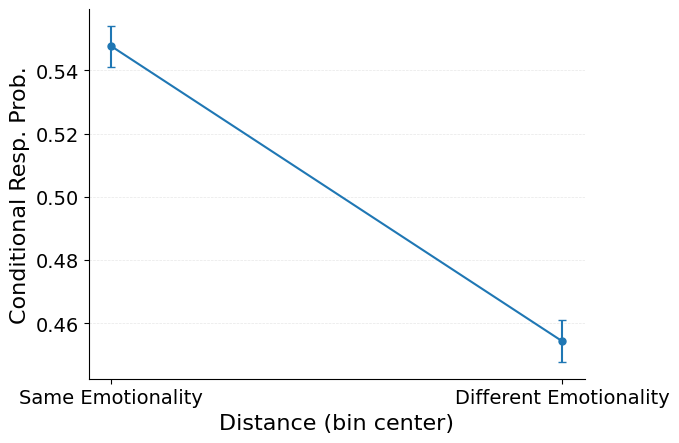

In [4]:
axis = plot_dist_crp(
    datasets=data,
    trial_masks=trial_mask,
    distances=category_distance,
    bin_edges=bin_edges,
    bin_centers=bin_centers,
)
axis.set_xticks(bin_centers)
axis.set_xticklabels(
    [f"Same {feature_label}", f"Different {feature_label}"]
);


## Notes

- Update `category_features_path` or `feature_column` to explore other categorical embeddings.
